[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# Torneio de modelos e contraprova
Este notebook apenas orquestra e apresenta as saídas; toda a lógica está em `src/`.

In [1]:
# Setup inicial para execução local ou no Colab.
import os
from pathlib import Path
import sys

IN_COLAB = 'google.colab' in sys.modules
RAIZ = Path.cwd()
if not (RAIZ / 'src').exists() and (RAIZ.parent / 'src').exists():
    RAIZ = RAIZ.parent
if IN_COLAB and not (RAIZ / 'src').exists():
    raise FileNotFoundError('Clone o repositório, entre na pasta e envie data/raw/vendas.csv.')
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))
print('Ambiente:', 'Colab' if IN_COLAB else 'local')

Ambiente: local


## Execução ponta a ponta
O comando faz tuning sem junho, walk-forward, holdout, bootstrap, SHAP e todas as figuras.

In [2]:
from src.train import main
main()


Resumo holdout — total diario
       modelo     wape      bias    smape           mae  wape_ic_low  wape_ic_high
      xgboost 0.186379 -0.006498 0.186274 294977.285500     0.134251      0.241966
     lightgbm 0.200991 -0.005235 0.201100 318103.161002     0.154331      0.250747
        ridge 0.228337 -0.025336 0.223466 361383.156423     0.156587      0.304848
media_movel_7 0.311985 -0.024409 0.298085 493771.032143     0.135781      0.472999
naive_sazonal 0.350885 -0.022622 0.321457 555337.492000     0.146989      0.528877

Contraprova
   conjunto      modelo_a      modelo_b  diferenca    ic_low  ic_high  p_a_menor_b
walkforward naive_sazonal media_movel_7   0.080841  0.013841 0.157974       0.0010
walkforward naive_sazonal         ridge   0.055494 -0.029058 0.146084       0.1225
walkforward naive_sazonal       xgboost   0.075830 -0.009141 0.160508       0.0375
walkforward naive_sazonal      lightgbm   0.085856 -0.000190 0.173371       0.0260
walkforward media_movel_7         ridge  -0

## Resultados totais

In [3]:
import pandas as pd

metricas = pd.read_csv('reports/metrics/resumo_metricas.csv')
metricas.query("granularidade == 'total' and segmento == 'todos'").sort_values(['conjunto', 'wape'])

,modelo,conjunto,granularidade,segmento,wape,bias,smape,mae,wape_ic_low,wape_ic_high
81,xgboost,holdout,total,todos,0.186379,-0.006498,0.186274,294977.285500,0.134251,0.241966
91,lightgbm,holdout,total,todos,0.200991,-0.005235,0.201100,318103.161002,0.154331,0.250747
71,ridge,holdout,total,todos,0.228337,-0.025336,0.223466,361383.156423,0.156587,0.304848
61,media_movel_7,holdout,total,todos,0.311985,-0.024409,0.298085,493771.032143,0.135781,0.472999
51,naive_sazonal,holdout,total,todos,0.350885,-0.022622,0.321457,555337.492000,0.146989,0.528877
41,lightgbm,walkforward,total,todos,0.223132,-0.031744,0.220142,374078.323640,0.157644,0.285897
11,media_movel_7,walkforward,total,todos,0.228148,-0.032063,0.224625,382487.025276,0.173180,0.289266
31,xgboost,walkforward,total,todos,0.233159,-0.034098,0.231809,390887.874725,0.163866,0.306544
21,ridge,walkforward,total,todos,0.253494,-0.126609,0.263826,424979.644091,0.173908,0.325800
1,naive_sazonal,walkforward,total,todos,0.308988,-0.019215,0.288467,518015.395200,0.212927,0.404379


## Contraprova pareada

In [4]:
pd.read_csv('reports/metrics/contraprova.csv')

,conjunto,modelo_a,modelo_b,diferenca,ic_low,ic_high,p_a_menor_b
0,walkforward,naive_sazonal,media_movel_7,0.080841,0.013841,0.157974,0.0010
1,walkforward,naive_sazonal,ridge,0.055494,-0.029058,0.146084,0.1225
2,walkforward,naive_sazonal,xgboost,0.075830,-0.009141,0.160508,0.0375
3,walkforward,naive_sazonal,lightgbm,0.085856,-0.000190,0.173371,0.0260
4,walkforward,media_movel_7,ridge,-0.025346,-0.091662,0.051638,0.7380
5,walkforward,media_movel_7,xgboost,-0.005011,-0.062790,0.057122,0.5820
6,walkforward,media_movel_7,lightgbm,0.005016,-0.056855,0.076035,0.4540
7,walkforward,ridge,xgboost,0.020335,-0.049915,0.071623,0.2675
8,walkforward,ridge,lightgbm,0.030362,-0.019940,0.068620,0.1160
9,walkforward,xgboost,lightgbm,0.010027,-0.010907,0.040204,0.2070


## Decisão e importância por permutação

In [5]:
import json

display(json.loads(Path('reports/metrics/decisao.json').read_text(encoding='utf-8')))
pd.read_csv('reports/metrics/permutation_importance.csv').groupby('modelo').head(10)

{'holdout': {'candidato': 'xgboost',
  'empates': ['media_movel_7'],
  'vencedor': 'media_movel_7'},
 'walkforward': {'candidato': 'lightgbm',
  'empates': ['naive_sazonal', 'media_movel_7', 'ridge'],
  'vencedor': 'naive_sazonal'},
 'walkforward_concorda': False,
 'regra4_vencedor': 'naive_sazonal',
 'poder_estatistico': {'holdout': {'n_blocos_semanas': 5,
   'semi_largura_media_ic95_diferenca_wape': 0.09194754707774407},
  'walkforward': {'n_blocos_semanas': 11,
   'semi_largura_media_ic95_diferenca_wape': 0.06598976108694955}}}

,modelo,feature,wape_referencia,wape_permutado_media,wape_permutado_std,aumento_wape_media,aumento_wape_std
0,lightgbm,dias_ate_evento_presente,0.191370,0.258392,0.019154,0.067022,0.019154
1,lightgbm,media_7_lag7,0.191370,0.243084,0.021609,0.051713,0.021609
2,lightgbm,lag_7,0.191370,0.238347,0.018193,0.046977,0.018193
3,lightgbm,fourier_mes_sin1,0.191370,0.215859,0.010128,0.024489,0.010128
4,lightgbm,taxa_desconto_media_7_lag7,0.191370,0.208276,0.010773,0.016906,0.010773
5,lightgbm,canal,0.191370,0.207991,0.016411,0.016621,0.016411
6,lightgbm,share_canal_lag7,0.191370,0.205356,0.013897,0.013986,0.013897
7,lightgbm,std_7_lag7,0.191370,0.197035,0.005507,0.005665,0.005507
8,lightgbm,is_vespera_feriado,0.191370,0.195737,0.003101,0.004367,0.003101
9,lightgbm,ticket_lag_7,0.191370,0.193713,0.003787,0.002342,0.003787


## Visualizações

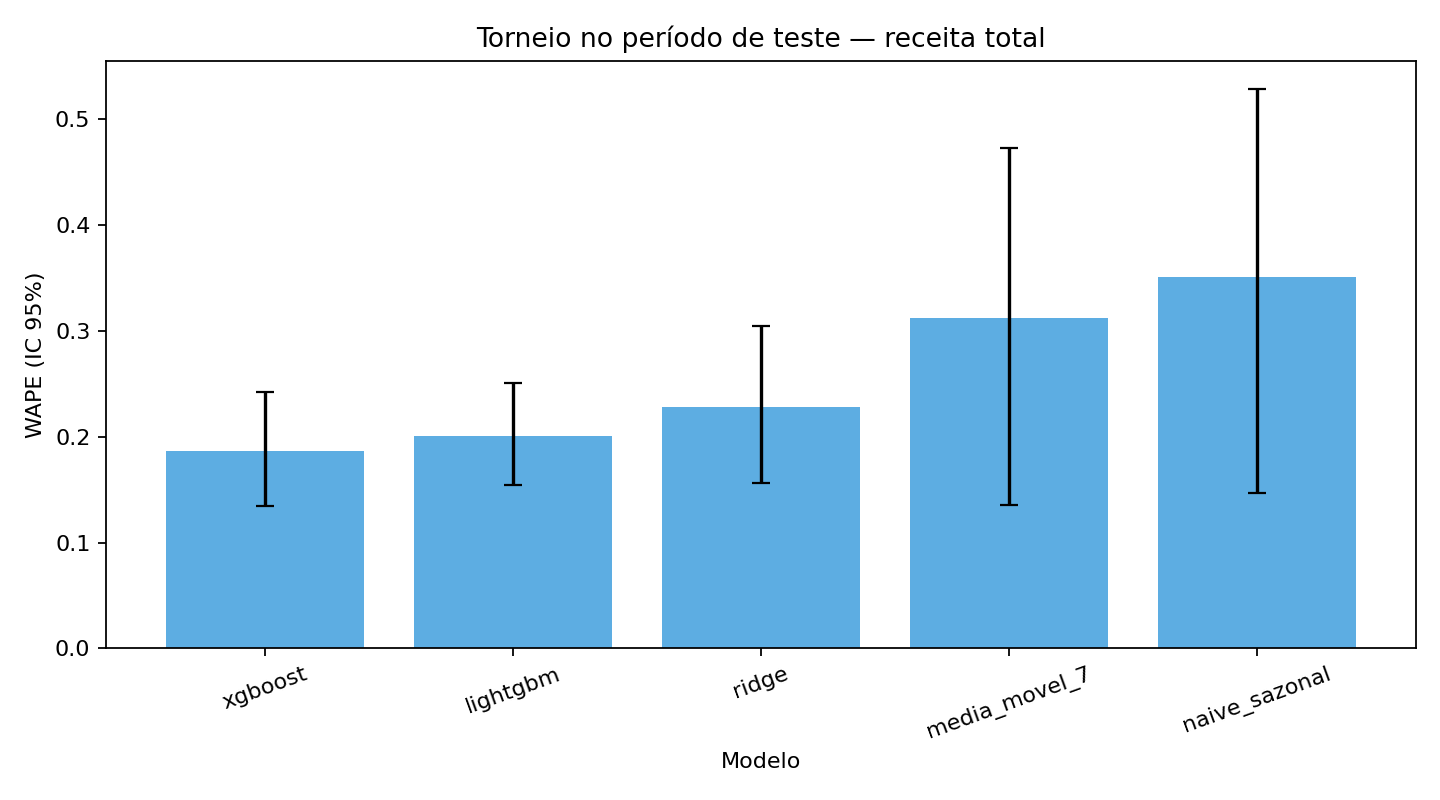

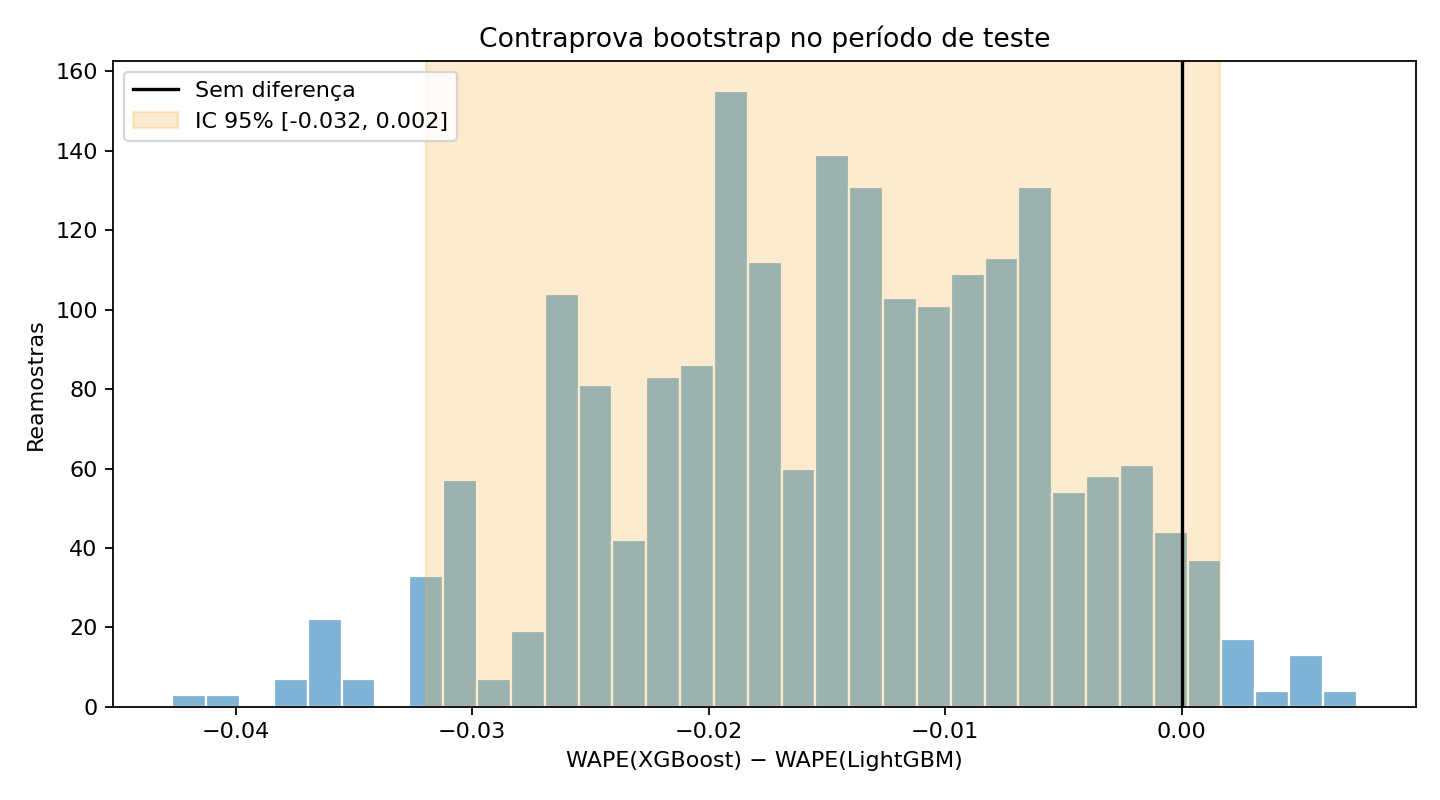

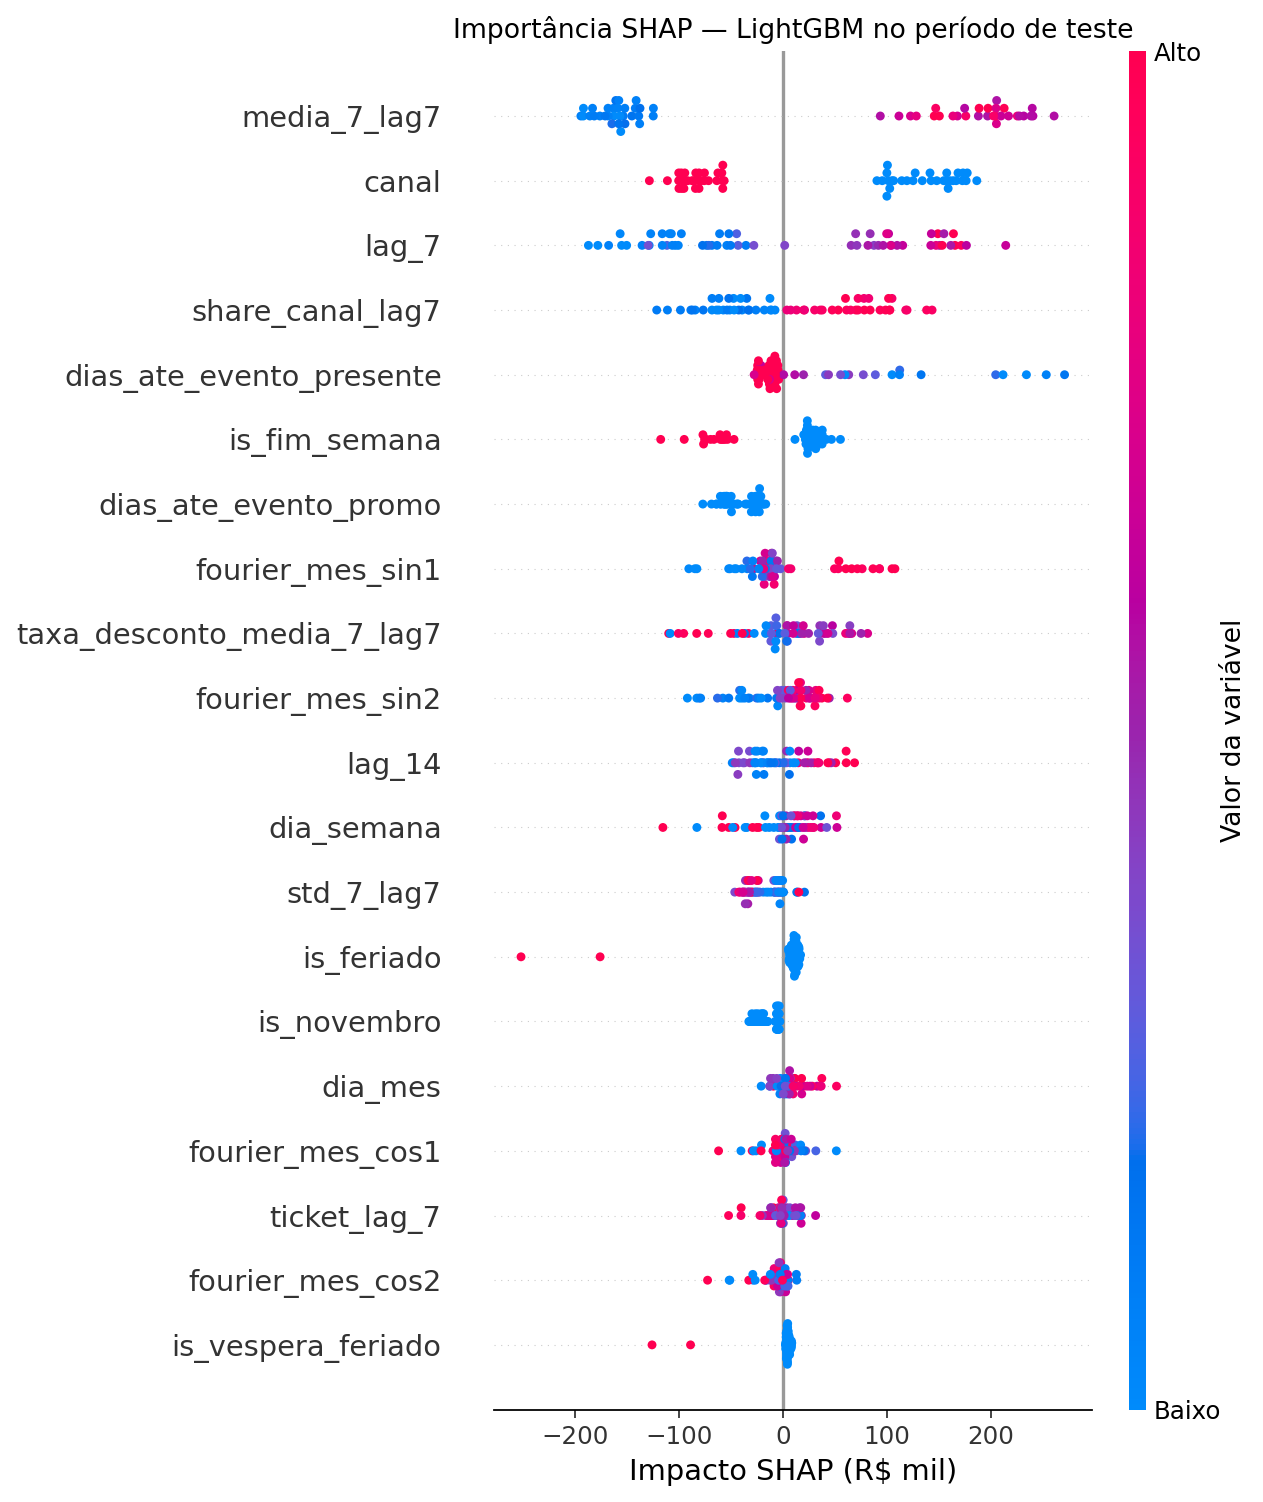

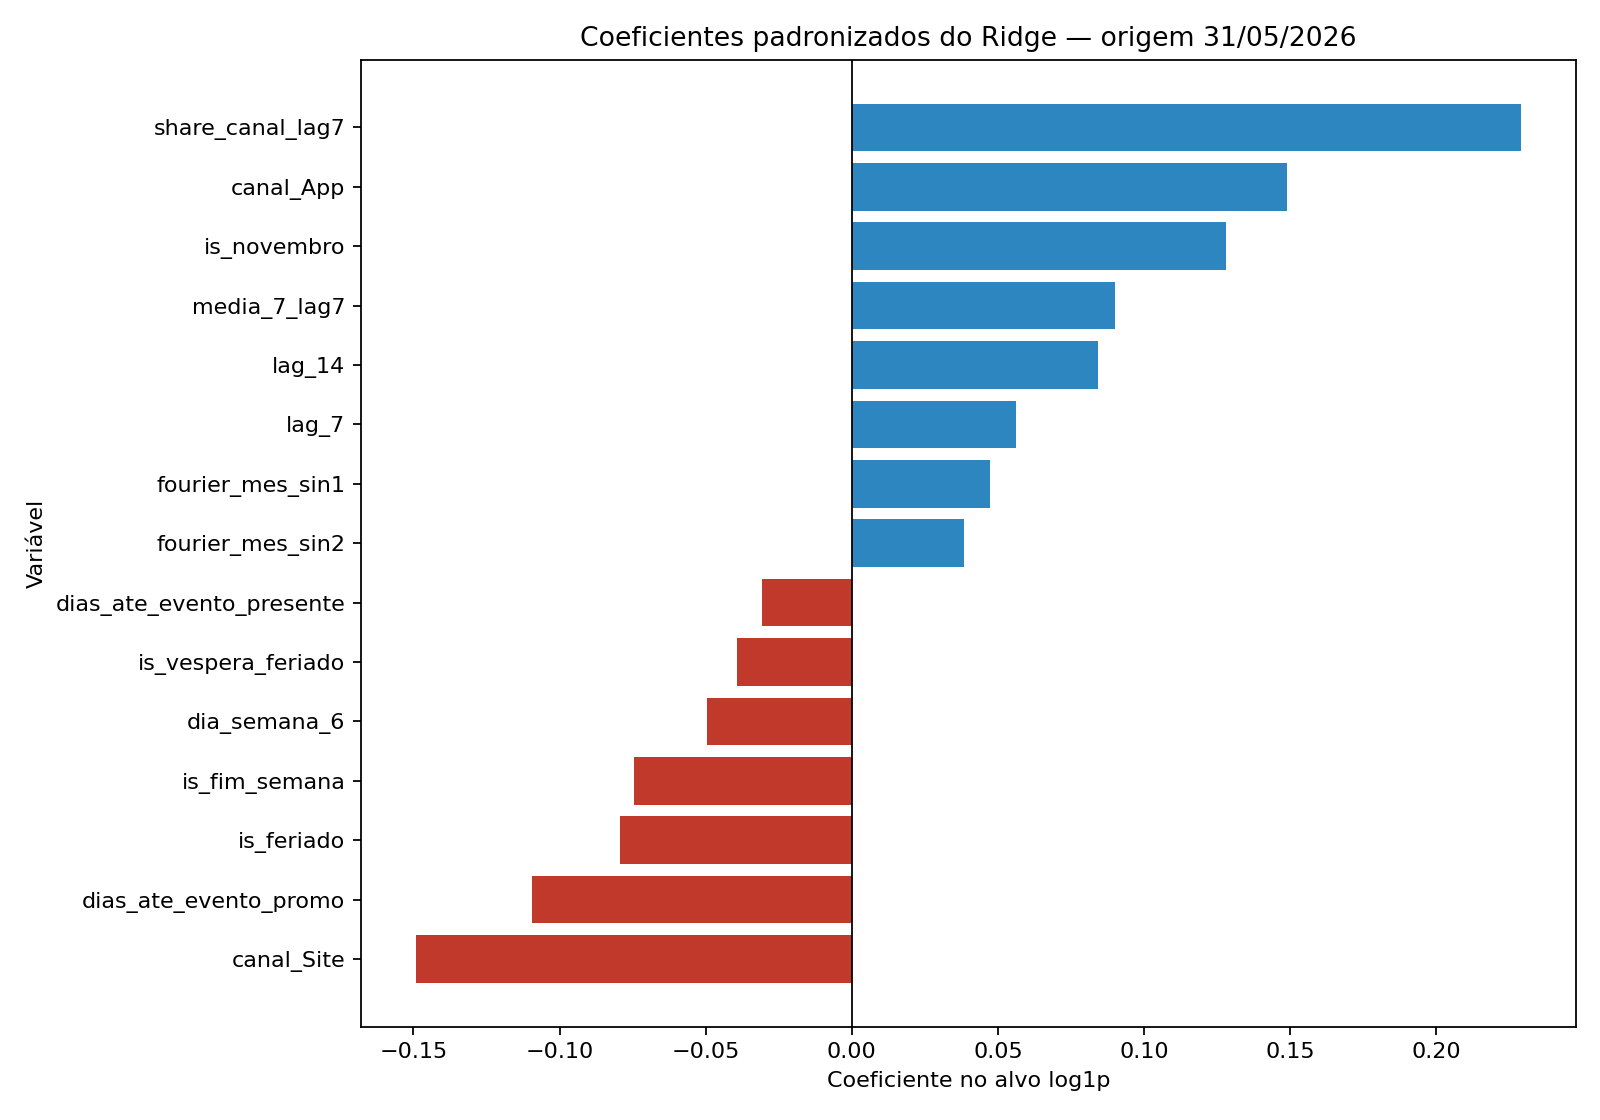

In [6]:
from IPython.display import Image, display

display(Image('reports/figures/torneio_wape.png'))
display(Image('reports/figures/contraprova_bootstrap.png'))
display(Image('reports/figures/shap_summary.png'))
display(Image('reports/figures/ridge_coeficientes.png'))